In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('titanic_train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

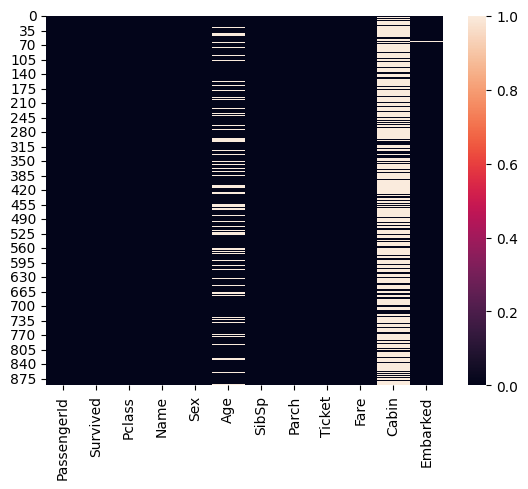

In [7]:
sns.heatmap(data=df.isnull())

In [8]:
df.drop(columns=['Cabin'],inplace=True)

<Axes: >

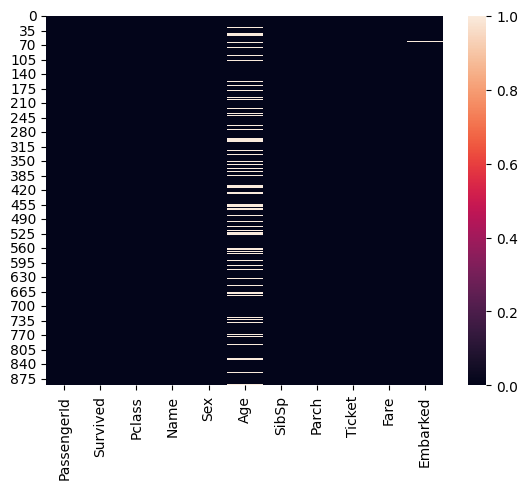

In [9]:
sns.heatmap(data=df.isnull())

<Axes: xlabel='Sex', ylabel='Age'>

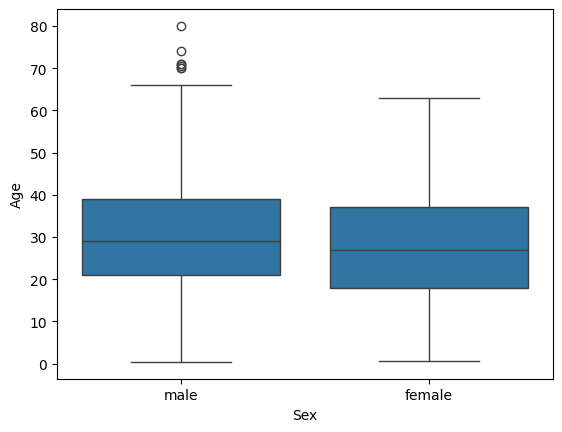

In [10]:
sns.boxplot(data=df,x='Sex',y='Age')

<Axes: xlabel='Pclass', ylabel='Age'>

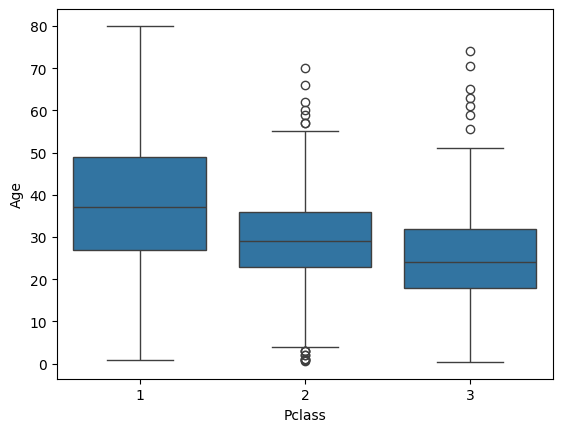

In [11]:
sns.boxplot(data=df,x='Pclass',y='Age')

In [19]:
pclass1_mdn=df[df['Pclass']==1]['Age'].median()
pclass2_mdn=df[df['Pclass']==2]['Age'].median()
pclass3_mdn=df[df['Pclass']==3]['Age'].median()
pclass1_mdn,pclass2_mdn,pclass3_mdn

(np.float64(37.0), np.float64(29.0), np.float64(24.0))

In [21]:
def fill_age(columns):
    age=columns.iloc[0]
    pclass=columns.iloc[1]
    if pd.isnull(age):
        if pclass == 1:
            return pclass1_mdn
        elif pclass == 2:
            return pclass2_mdn
        else:
            return pclass3_mdn
    else:
        return age

In [25]:
df['Age']=df[['Age','Pclass']].apply(fill_age,axis=1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


<Axes: >

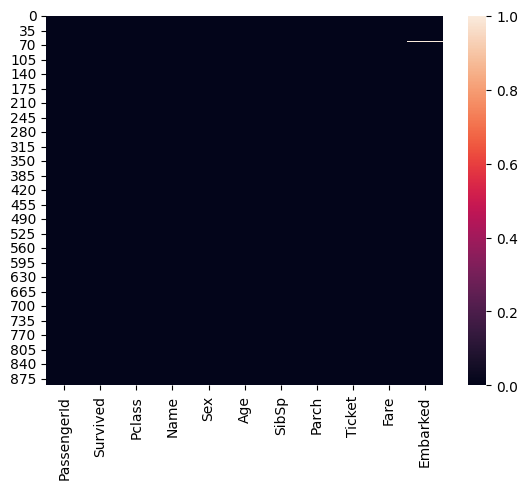

In [27]:
sns.heatmap(data=df.isnull())

<Axes: xlabel='Survived', ylabel='count'>

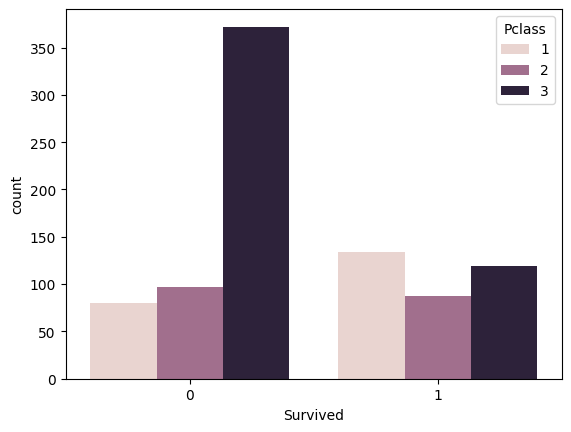

In [41]:
sns.countplot(data=df,x='Survived',hue='Pclass')

In [28]:
df.dropna(inplace=True)

In [38]:
df.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

In [50]:
df=pd.get_dummies(
    data=df,
    columns=['Sex','Embarked'],
    drop_first=True,
    dtype=int
)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_male    889 non-null    int64  
 7   Embarked_Q  889 non-null    int64  
 8   Embarked_S  889 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 69.5 KB


In [52]:
feature=df.drop(columns='Survived')
target=df['Survived']

In [53]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(feature,target,test_size=.20,random_state=42)

In [67]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
DT.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [68]:
DT_predict=DT.predict(x_test)

In [69]:
from sklearn.metrics import classification_report
print(classification_report(y_test,DT_predict))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       109
           1       0.78      0.67      0.72        69

    accuracy                           0.80       178
   macro avg       0.79      0.77      0.78       178
weighted avg       0.80      0.80      0.79       178



In [70]:
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold
cv=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [71]:

scores = cross_val_score(
    DT,
    feature,
    target,
    cv=cv
)


In [72]:
print("Accuracy scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Accuracy scores: [0.79775281 0.79775281 0.79213483 0.81460674 0.8079096 ]
Mean Accuracy: 0.802031359106202
Std Dev: 0.008090083497502752


In [73]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [74]:
scores = cross_val_score(
    DT,
    feature,
    target,
    cv=cv
)

In [75]:
print("Accuracy scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

Accuracy scores: [0.83146067 0.79213483 0.76966292 0.83707865 0.78531073]
Mean Accuracy: 0.8031295626229923
Std Dev: 0.02650887910667477


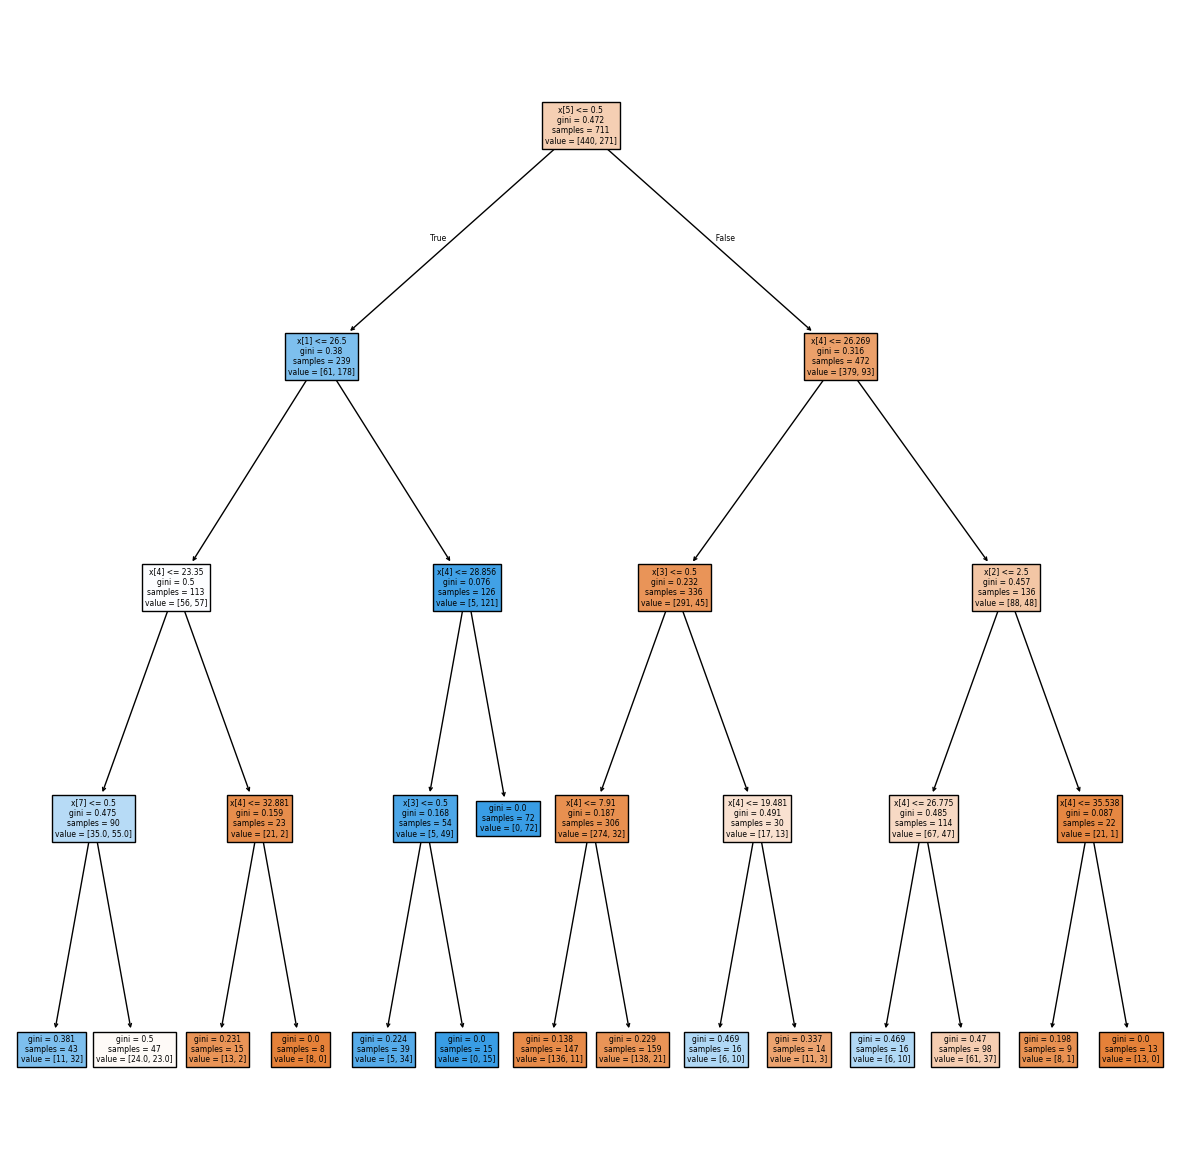

In [81]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,15))
plot_tree(DT,filled=True);
plt.show()